In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 
# import column transformer
from sklearn.compose import ColumnTransformer

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn import metrics 

from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
df = pd.read_csv('../data/churn.csv', header='infer')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Feature Engineering

Binary columns

In [4]:
df.drop(['customerID'], axis=1, inplace=True)

In [14]:
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
# df = pd.get_dummies(df.gender, prefix='gender', drop_first=True).join(df.drop('gender', axis=1))

In [15]:
columnas_binarias = [
    col for col in df.select_dtypes(include=['object', 'category']).columns
     if df[col].nunique() == 2
]

for c in columnas_binarias:
    df[c] = df[c].map({'Yes': 1, 'No': 0})

Total charges

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df['TotalCharges'].dtype
df['TotalCharges'].isna().sum()

np.int64(11)

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

df['TotalCharges'].isna().sum()

np.int64(0)

Categorical columns

In [ ]:
# columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns
# df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## Model creation

In [17]:
X = df.drop('Churn', axis=1) 
y = df['Churn'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Identificar columnas
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [19]:
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
scale_pos_weight = negatives / positives
print(f'Negatives: {negatives}, Positives: {positives}, Scale_Pos_Weight: {scale_pos_weight:.2f}')

Negatives: 4139, Positives: 1495, Scale_Pos_Weight: 2.77


In [20]:
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.8)),
    ('xgb', xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss'
    ))
])

In [21]:
param_dist = {
    'xgb__n_estimators': [200, 300, 400, 500],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__gamma': [0, 0.1, 0.2],
    'xgb__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'xgb__reg_lambda': [0, 0.1, 1]   # L2 regularization
}

# Búsqueda con optimización de recall
random_search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',  # Optimizar recall para detectar churn
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor recall:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores parámetros: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 0, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 1, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.9}
Mejor recall: 0.9016722408026755


In [22]:
xgboost_pred = random_search.predict(X_test)
print("Accuracy XGBoost Classifier:", f"{metrics.accuracy_score(y_test, xgboost_pred)*100:.2f}%")
print(metrics.classification_report(y_test, xgboost_pred))

Accuracy XGBoost Classifier: 65.15%
              precision    recall  f1-score   support

           0       0.94      0.56      0.70      1035
           1       0.43      0.91      0.58       374

    accuracy                           0.65      1409
   macro avg       0.68      0.73      0.64      1409
weighted avg       0.81      0.65      0.67      1409



Accuracy:  0.6515259048970902
Precision:  0.42641509433962266
Recall:  0.9064171122994652
F1 score:  0.5799828913601369
Confusion matriz:
 [[579 456]
 [ 35 339]]


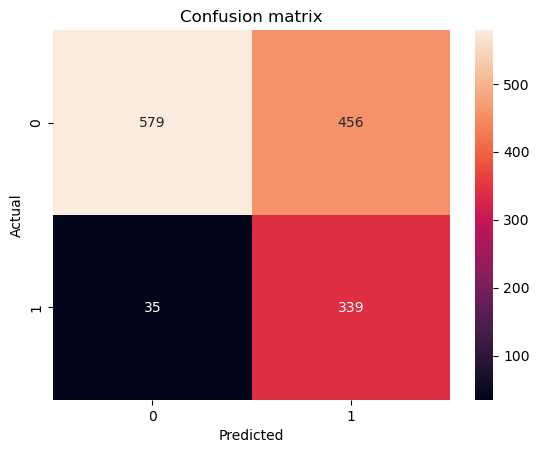

In [16]:
print("Accuracy: ", metrics.accuracy_score(y_test, xgboost_pred))
print("Precision: ", metrics.precision_score(y_test, xgboost_pred))
print("Recall: ", metrics.recall_score(y_test, xgboost_pred))
print("F1 score: ", metrics.f1_score(y_test, xgboost_pred))
matriz_confusion = metrics.confusion_matrix(y_test, xgboost_pred)
print("Confusion matriz:\n", matriz_confusion)
sns.heatmap(matriz_confusion, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
import joblib
import pickle


# joblib.dump(random_search.best_estimator_, '../models/xgboost_churn_model.pkl')
# joblib.dump(preprocessor, '../models/preprocessor.pkl')

best_pipeline = random_search.best_estimator_
best_preprocessor = best_pipeline.named_steps['preprocessor']
best_model = best_pipeline.named_steps['xgb']

joblib.dump(best_preprocessor, '../models/preprocessor.pkl')
joblib.dump(best_model, '../models/xgboost_churn_model.pkl')

original_columns = X_train.columns.tolist()
with open('../models/column_names.pkl', 'wb') as f:
    pickle.dump(original_columns, f)

print("Model, preprocessor and column names saved successfully.")

Model, preprocessor and column names saved successfully.
